# **Importing Library**

## Pip install thing (just to shorten the installation log)

 <!-- Remember to uncomment -->

<!-- !pip install --user matplotlib
!pip install --user scikit-learn
!pip install --user numpy==1.26.4 
!pip install --user seaborn
!pip install --user pandas
!pip install --user opencv-python
!pip install --user Pillow -->

## Importing Library

### Run this if you're on Jupyter Lab

In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os
import seaborn as sns
import glob
import cv2
import zipfile
from tensorflow.keras import layers, models, Model, optimizers, losses
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential  # Sequential API for building models layer by layer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2, VGG19
import shutil
from PIL import Image
import hashlib
import random
from pathlib import Path
from tqdm import tqdm
from tensorflow.keras.callbacks import TensorBoard, CSVLogger
from tensorflow.keras.models import Model
from tensorflow.keras import layers, optimizers
from tensorflow.keras.regularizers import l2


import warnings
warnings.filterwarnings('ignore')

print("TF version:", tf.__version__)
#print("Hub version:", hub.__version__)
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")
# Check for GPU availability in TensorFlow
device = "GPU" if len(tf.config.list_physical_devices('GPU')) > 0 else "CPU"
print("The device is:", device)

# rm -rf '/content/__MACOSX'
# use this one when you need to remove folder and not getting must be empty error

TF version: 2.10.0
GPU is available
The device is: GPU


# **Extracting Data**

## Loading and Unzipping Data From Drive

### If using Jupyter

In [10]:
# Define the extraction paths
train_extract_path = 'dataset/train_images/'
test_extract_path = 'dataset/test_images/'

# For train images: remove if exists, then extract
if os.path.exists(train_extract_path):
    print(f"Removing existing train images folder: {train_extract_path}")
    shutil.rmtree(train_extract_path)
    
# Create directory if it doesn't exist
os.makedirs(train_extract_path, exist_ok=True)

# Extract train images
with zipfile.ZipFile('zip_data/train_images.zip', 'r') as train_zip_ref:
    print("Extracting train images...")
    train_zip_ref.extractall(train_extract_path)
    print("Train images extracted successfully.")

# For test images: remove if exists, then extract
if os.path.exists(test_extract_path):
    print(f"Removing existing test images folder: {test_extract_path}")
    shutil.rmtree(test_extract_path)
    
# Create directory if it doesn't exist
os.makedirs(test_extract_path, exist_ok=True)

# Extract test images
with zipfile.ZipFile('zip_data/test_images.zip', 'r') as test_zip_ref:
    print("Extracting test images...")
    test_zip_ref.extractall(test_extract_path)
    print("Test images extracted successfully.")

print("All extraction complete!")

Removing existing train images folder: dataset/train_images/
Extracting train images...
Train images extracted successfully.
Removing existing test images folder: dataset/test_images/
Extracting test images...
Test images extracted successfully.
All extraction complete!


### Check Class Names

In [11]:
CLASS_NAMES = [os.path.basename(l) for l in glob.glob('dataset/train_images/train_images/*')
               if '.' not in l]
print(CLASS_NAMES)

['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


### Read The CSV File

In [12]:
train_df = pd.read_csv('opencv/meta_train.csv')
train_df

,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45
...,...,...,...,...
10402,107607.jpg,tungro,Zonal,55
10403,107811.jpg,tungro,Zonal,55
10404,108547.jpg,tungro,Zonal,55
10405,110245.jpg,tungro,Zonal,55


### Add path to the csv file

In [13]:
train_df['path'] = 'dataset/train_images/train_images/' + train_df['label'] + "/" + train_df["image_id"]
train_df.head()

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...


### Load some images for testing

bacterial_leaf_blight: (640, 480, 3)
bacterial_leaf_streak: (640, 480, 3)
bacterial_panicle_blight: (640, 480, 3)
blast: (640, 480, 3)
brown_spot: (640, 480, 3)
dead_heart: (640, 480, 3)
downy_mildew: (640, 480, 3)
hispa: (640, 480, 3)
normal: (640, 480, 3)
tungro: (640, 480, 3)


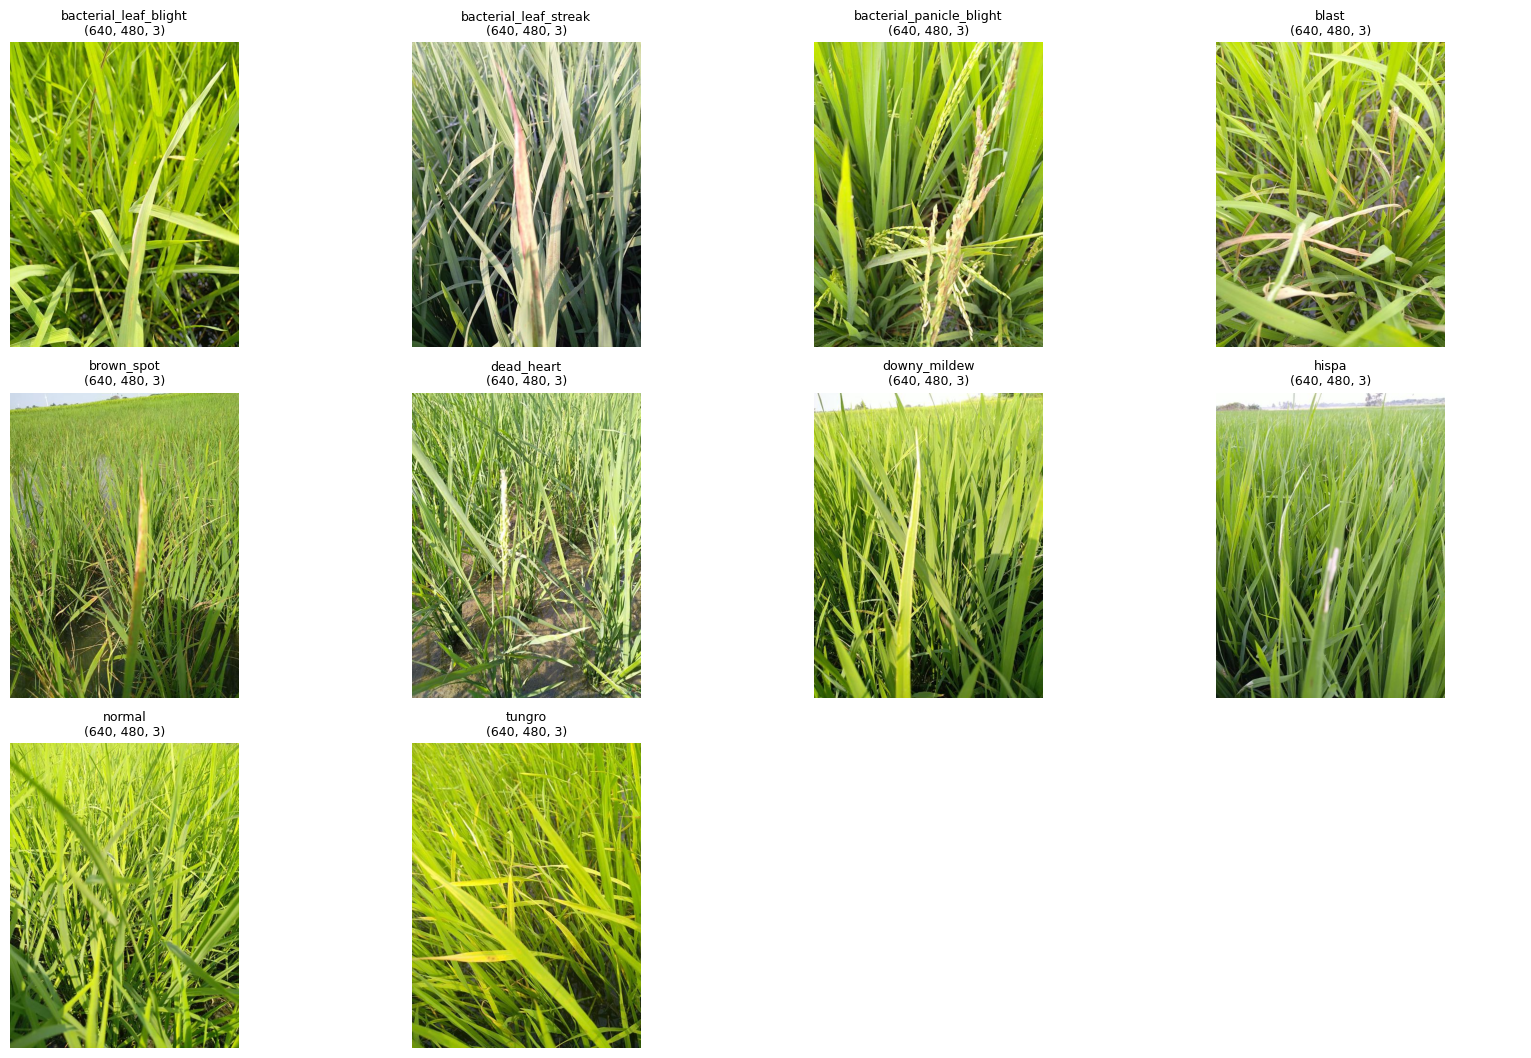

In [14]:
# Select one image per label
unique_labels = train_df.groupby("label").first().reset_index()
images_per_row = 4  # Changed to 4 images per row
num_rows = (len(unique_labels) + images_per_row - 1) // images_per_row  # Calculate number of rows

# Create subplots with the calculated number of rows and columns
fig, axes = plt.subplots(num_rows, images_per_row, figsize=(16, num_rows * 3.5))  # Adjusted figure size
axes = axes.flatten()  # Flatten axes array for easier iteration

for idx, (_, row) in enumerate(unique_labels.iterrows()):  # Plot images
    img_path, label = row["path"], row["label"]
    if not os.path.exists(img_path):  # Check if the image exists
        print(f"Image not found: {img_path}")
        axes[idx].axis("off")
        continue
    img = cv2.imread(img_path)
    if img is None:
        print(f"Failed to load image: {img_path}")
        axes[idx].axis("off")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img_shape = img.shape
    print(f"{label}: {img_shape}")
    axes[idx].imshow(img)
    axes[idx].set_title(f"{label}\n{img_shape}", fontsize=9)  # Smaller title font
    axes[idx].axis("off")

for idx in range(len(unique_labels), len(axes)):  # Turn off axis for any remaining unused subplots
    axes[idx].axis("off")

plt.tight_layout(pad=0.4, w_pad=0.2, h_pad=0.2)  # Even tighter spacing
plt.subplots_adjust(wspace=0.05, hspace=0.15)  # Further reduced space between subplots
plt.show()

# **Data Loading and Preprocessing**

### Check duplicates in dataset

In [15]:
def calculate_hash(image_path):
    with Image.open(image_path) as img:
        return hashlib.md5(img.tobytes()).hexdigest()

def find_duplicates_in_dataset(root_folder):
    hashes = {}
    duplicates = []

    for subdir, _, files in os.walk(root_folder):
        for file in files:
            if file.lower().endswith(('.png', '.jpg')):
                path = os.path.join(subdir, file)
                try:
                    file_hash = calculate_hash(path)
                    if file_hash in hashes:
                        duplicates.append((path, hashes[file_hash]))
                    else:
                        hashes[file_hash] = path
                except Exception as e:
                    print(f"Error processing {file}: {e}")
    
    return duplicates
    
# Function to delete duplicate files, keeping only the first occurrence
def remove_duplicate_files(duplicates):
    removed_count = 0
    for duplicate_path, original_path in duplicates:
        try:
            # Check if file exists before attempting to remove
            if os.path.exists(duplicate_path):
                os.remove(duplicate_path)
                print(f"Removed: {duplicate_path}")
                removed_count += 1
            else:
                print(f"File not found: {duplicate_path}")
        except Exception as e:
            print(f"Error removing {duplicate_path}: {e}")
    
    return removed_count

duplicates = find_duplicates_in_dataset('dataset/train_images/train_images')
for dup1, dup2 in duplicates:
    print(f"Duplicate found:\n -> {dup1}\n -> {dup2}\n")

Duplicate found:
 -> dataset/train_images/train_images\bacterial_leaf_blight\100513.jpg
 -> dataset/train_images/train_images\bacterial_leaf_blight\100169.jpg

Duplicate found:
 -> dataset/train_images/train_images\bacterial_leaf_blight\103032.jpg
 -> dataset/train_images/train_images\bacterial_leaf_blight\100133.jpg

Duplicate found:
 -> dataset/train_images/train_images\bacterial_leaf_blight\104800.jpg
 -> dataset/train_images/train_images\bacterial_leaf_blight\102353.jpg

Duplicate found:
 -> dataset/train_images/train_images\bacterial_leaf_blight\105878.jpg
 -> dataset/train_images/train_images\bacterial_leaf_blight\103344.jpg

Duplicate found:
 -> dataset/train_images/train_images\bacterial_leaf_blight\106984.jpg
 -> dataset/train_images/train_images\bacterial_leaf_blight\100998.jpg

Duplicate found:
 -> dataset/train_images/train_images\bacterial_leaf_blight\107812.jpg
 -> dataset/train_images/train_images\bacterial_leaf_blight\100635.jpg

Duplicate found:
 -> dataset/train_image

Then we will remove these dulpicate ones from the dataframe

Then we need to remove it from the dataset as well.

In [16]:
# Remove the duplicate files from the filesystem
if duplicates:
    removed_count = remove_duplicate_files(duplicates)
    print(f"\n✅ Removed {removed_count} duplicate image files")
else:
    print("No duplicates found.")

# If you also need to update your dataframe after removing files
if 'train_df' in locals() or 'train_df' in globals():
    # Extract ONLY the duplicate paths (not the originals) to remove from dataframe
    paths_to_remove = [duplicate_path for duplicate_path, original_path in duplicates]
    
    # Normalize paths to ensure consistent comparison
    train_df['path'] = train_df['path'].apply(os.path.normpath)
    paths_to_remove = [os.path.normpath(path) for path in paths_to_remove]
    
    # Remove only the duplicate entries from dataframe
    original_length = len(train_df)
    train_df = train_df[~train_df['path'].isin(paths_to_remove)].reset_index(drop=True)
    removed_count = original_length - len(train_df)
    
    print(f"Removed {removed_count} duplicate image entries from dataframe")

Removed: dataset/train_images/train_images\bacterial_leaf_blight\100513.jpg
Removed: dataset/train_images/train_images\bacterial_leaf_blight\103032.jpg
Removed: dataset/train_images/train_images\bacterial_leaf_blight\104800.jpg
Removed: dataset/train_images/train_images\bacterial_leaf_blight\105878.jpg
Removed: dataset/train_images/train_images\bacterial_leaf_blight\106984.jpg
Removed: dataset/train_images/train_images\bacterial_leaf_blight\107812.jpg
Removed: dataset/train_images/train_images\bacterial_leaf_blight\108125.jpg
Removed: dataset/train_images/train_images\bacterial_leaf_blight\108353.jpg
Removed: dataset/train_images/train_images\bacterial_panicle_blight\104803.jpg
Removed: dataset/train_images/train_images\blast\102705.jpg
Removed: dataset/train_images/train_images\blast\105626.jpg
Removed: dataset/train_images/train_images\blast\105840.jpg
Removed: dataset/train_images/train_images\blast\105962.jpg
Removed: dataset/train_images/train_images\blast\106520.jpg
Removed: data

In [17]:
train_df

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset\train_images\train_images\bacterial_le...
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset\train_images\train_images\bacterial_le...
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset\train_images\train_images\bacterial_le...
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset\train_images\train_images\bacterial_le...
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset\train_images\train_images\bacterial_le...
...,...,...,...,...,...
10328,107607.jpg,tungro,Zonal,55,dataset\train_images\train_images\tungro\10760...
10329,107811.jpg,tungro,Zonal,55,dataset\train_images\train_images\tungro\10781...
10330,108547.jpg,tungro,Zonal,55,dataset\train_images\train_images\tungro\10854...
10331,110245.jpg,tungro,Zonal,55,dataset\train_images\train_images\tungro\11024...


## Remapping the dataset

In [18]:
# Define output base directory
output_base_dir = 'dataset/train_images_by_disease'

# Reset output directory
if os.path.exists(output_base_dir):
    shutil.rmtree(output_base_dir)
    print(f"Removed existing directory: {output_base_dir}")

os.makedirs(output_base_dir, exist_ok=True)

# Get unique disease labels
labels = train_df['label'].unique()
print(f"Found {len(labels)} unique disease labels: {labels}")

# Create label directories
for label in labels:
    label_dir = os.path.join(output_base_dir, label)
    os.makedirs(label_dir, exist_ok=True)

# Move files
print("Copying images to disease folders...")
for idx, row in tqdm(train_df.iterrows(), total=len(train_df)):
    src_path = row['path']
    dst_path = os.path.join(output_base_dir, row['label'], row['image_id'])

    try:
        shutil.copy2(src_path, dst_path)
    except FileNotFoundError:
        print(f"Warning: Could not find {src_path}")

print("Done. Images have been sorted into directories by disease label.")
print(f"New structure: {output_base_dir}/[label]/[image_id].jpg")

# Count files in each disease label directory
for label in labels:
    label_dir = os.path.join(output_base_dir, label)
    file_count = len([f for f in os.listdir(label_dir) if os.path.isfile(os.path.join(label_dir, f))])
    print(f"Disease '{label}': {file_count} images")


Removed existing directory: dataset/train_images_by_disease
Found 10 unique disease labels: ['bacterial_leaf_blight' 'bacterial_leaf_streak'
 'bacterial_panicle_blight' 'blast' 'brown_spot' 'dead_heart'
 'downy_mildew' 'hispa' 'normal' 'tungro']
Copying images to disease folders...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10333/10333 [00:07<00:00, 1315.03it/s]


Done. Images have been sorted into directories by disease label.
New structure: dataset/train_images_by_disease/[label]/[image_id].jpg
Disease 'bacterial_leaf_blight': 471 images
Disease 'bacterial_leaf_streak': 380 images
Disease 'bacterial_panicle_blight': 336 images
Disease 'blast': 1728 images
Disease 'brown_spot': 953 images
Disease 'dead_heart': 1429 images
Disease 'downy_mildew': 618 images
Disease 'hispa': 1589 images
Disease 'normal': 1749 images
Disease 'tungro': 1080 images


Map the image on the new path

In [19]:
train_df = train_df.drop('path', axis=1)
train_df['path'] = 'dataset/train_images_by_disease/' + train_df["image_id"]

In [20]:
train_df

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_disease/100330.jpg
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_disease/100365.jpg
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_disease/100382.jpg
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_disease/100632.jpg
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_disease/101918.jpg
...,...,...,...,...,...
10328,107607.jpg,tungro,Zonal,55,dataset/train_images_by_disease/107607.jpg
10329,107811.jpg,tungro,Zonal,55,dataset/train_images_by_disease/107811.jpg
10330,108547.jpg,tungro,Zonal,55,dataset/train_images_by_disease/108547.jpg
10331,110245.jpg,tungro,Zonal,55,dataset/train_images_by_disease/110245.jpg


In [21]:
def check_total_images(data_dir):
    """
    Prints the number of images per class and the total in the dataset directory.
    """
    total = 0
    print("Image Count Per Class:")
    print("-" * 30)
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        count = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        total += count
        print(f"{class_name:25}: {count} images")
    print("-" * 30)
    print(f"Total images in dataset: {total}")

check_total_images('dataset/train_images_by_disease')

Image Count Per Class:
------------------------------
bacterial_leaf_blight    : 471 images
bacterial_leaf_streak    : 380 images
bacterial_panicle_blight : 336 images
blast                    : 1728 images
brown_spot               : 953 images
dead_heart               : 1429 images
downy_mildew             : 618 images
hispa                    : 1589 images
normal                   : 1749 images
tungro                   : 1080 images
------------------------------
Total images in dataset: 10333


### Data Distribution

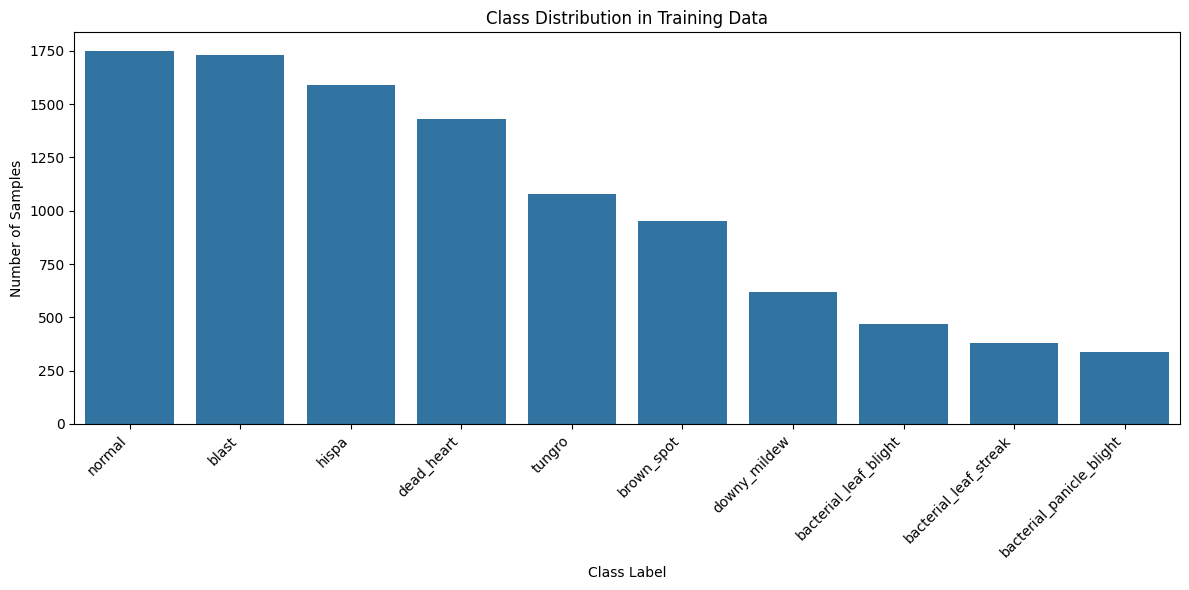

Class distribution:
normal: 1749 samples (16.93%)
blast: 1728 samples (16.72%)
hispa: 1589 samples (15.38%)
dead_heart: 1429 samples (13.83%)
tungro: 1080 samples (10.45%)
brown_spot: 953 samples (9.22%)
downy_mildew: 618 samples (5.98%)
bacterial_leaf_blight: 471 samples (4.56%)
bacterial_leaf_streak: 380 samples (3.68%)
bacterial_panicle_blight: 336 samples (3.25%)


In [22]:
# Visualize class distribution
plt.figure(figsize=(12, 6))
class_counts = train_df['label'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the exact counts
print("Class distribution:")
for label, count in class_counts.items():
    print(f"{label}: {count} samples ({count/len(train_df)*100:.2f}%)")

In order to handle imbalance in dataset, I will perform data augmentation with class weighting, this way instead of physically duplicating images, we will apply data augmentation which create variety in the dataset and class weights will help making the model pay more attention to underrespresented class.

### Augmentating the Data before Splitting and Loading

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
from tqdm import tqdm

train_data_path = 'dataset/train_images_by_disease'

# Step 1: Calculate average image count across classes
class_counts = {}
for class_name in os.listdir(train_data_path):
    class_path = os.path.join(train_data_path, class_name)
    if not os.path.isdir(class_path): continue

    image_files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    class_counts[class_name] = len(image_files)

average_count = int(np.mean(list(class_counts.values())))
print(f"Target average image count per class: {average_count}")

# Step 2: Define augmentation generator
augmentor = ImageDataGenerator(
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True,
    fill_mode='nearest'
)

# Step 3: Augment underrepresented classes until target average is met
for class_name, count in class_counts.items():
    if count >= average_count:
        print(f"Skipping '{class_name}' ({count} images already >= average)")
        continue

    class_path = os.path.join(train_data_path, class_name)
    images = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    current_count = count
    augment_index = 0

    print(f"Augmenting '{class_name}' from {current_count} to {average_count}")
    pbar = tqdm(total=average_count - current_count)

    while current_count < average_count:
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            img = load_img(img_path)
            x = img_to_array(img).reshape((1,) + img_to_array(img).shape)

            batch = next(augmentor.flow(x, batch_size=1))
            new_img = array_to_img(batch[0])
            new_img.save(os.path.join(class_path, f'aug_{augment_index}.jpg'))

            current_count += 1
            augment_index += 1
            pbar.update(1)

            if current_count >= average_count:
                break

    pbar.close()

Target average image count per class: 1033
Augmenting 'bacterial_leaf_blight' from 471 to 1033


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 562/562 [00:29<00:00, 19.16it/s]


Augmenting 'bacterial_leaf_streak' from 380 to 1033


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 653/653 [00:32<00:00, 20.15it/s]


Augmenting 'bacterial_panicle_blight' from 336 to 1033


...

Skipping 'blast' (1728 images already >= average)
Augmenting 'brown_spot' from 953 to 1033


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:04<00:00, 18.35it/s]


Skipping 'dead_heart' (1429 images already >= average)
Augmenting 'downy_mildew' from 618 to 1033


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 415/415 [00:22<00:00, 18.38it/s]

Skipping 'hispa' (1589 images already >= average)
Skipping 'normal' (1749 images already >= average)
Skipping 'tungro' (1080 images already >= average)


### Data Normalization and Data 

In [24]:
check_total_images('dataset/train_images_by_disease')

Image Count Per Class:
------------------------------
bacterial_leaf_blight    : 1033 images
bacterial_leaf_streak    : 1033 images
bacterial_panicle_blight : 1033 images
blast                    : 1728 images
brown_spot               : 1033 images
dead_heart               : 1429 images
downy_mildew             : 1033 images
hispa                    : 1589 images
normal                   : 1749 images
tungro                   : 1080 images
------------------------------
Total images in dataset: 12740


In [26]:
BATCH_SIZE = 32
IMAGE_SHAPE = (224,224)
train_data_path = 'dataset/train_images_by_disease'

# For training data - with augmentation
data_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

With these parameters as data augmentation parameters, I split the dataset with the reatio of 0.8-0.2.

In [27]:
# For training data (with augmentation)
train_gen = data_gen.flow_from_directory(
    train_data_path,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    subset='training',
    seed=42,
    class_mode='categorical',
    color_mode='rgb'
)

Found 10198 images belonging to 10 classes.


In [28]:
# For validation data (without augmentation)
valid_gen = data_gen.flow_from_directory(
    train_data_path,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    subset='validation',
    seed=42,
    class_mode='categorical',
    color_mode='rgb'
)

Found 2542 images belonging to 10 classes.


## Data Distribution from Image Folder, not csv

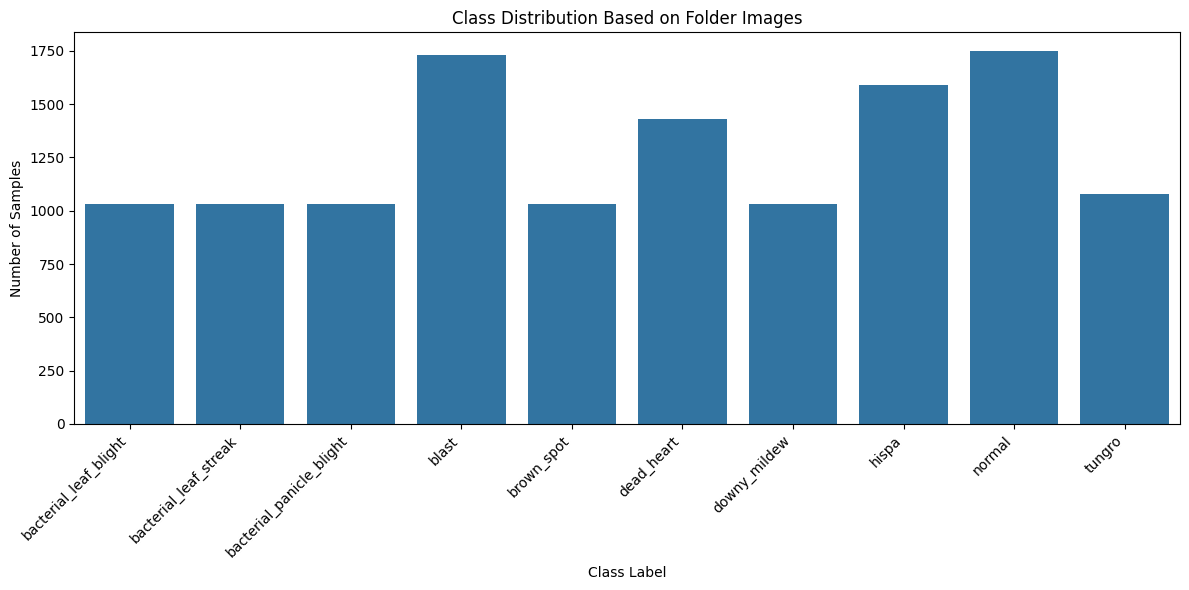

Updated Class Distribution:
bacterial_leaf_blight: 1033 samples (8.11%)
bacterial_leaf_streak: 1033 samples (8.11%)
bacterial_panicle_blight: 1033 samples (8.11%)
blast: 1728 samples (13.56%)
brown_spot: 1033 samples (8.11%)
dead_heart: 1429 samples (11.22%)
downy_mildew: 1033 samples (8.11%)
hispa: 1589 samples (12.47%)
normal: 1749 samples (13.73%)
tungro: 1080 samples (8.48%)


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

folder_counts = {}
for class_name in os.listdir(train_data_path):
    class_folder = os.path.join(train_data_path, class_name)
    if os.path.isdir(class_folder):
        count = len([f for f in os.listdir(class_folder) if f.endswith('.jpg')])
        folder_counts[class_name] = count

# Plot the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(folder_counts.keys()), y=list(folder_counts.values()))
plt.title('Class Distribution Based on Folder Images')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print counts
print("Updated Class Distribution:")
total_imgs = sum(folder_counts.values())
for label, count in folder_counts.items():
    print(f"{label}: {count} samples ({(count/total_imgs)*100:.2f}%)")


### Data Class Weighting

Calculating class weighting on the dataframe

Adding some functions to check the value in order to calculate class weighting

In [30]:
def get_class_counts_from_folders(data_dir):
    """
    Returns a dictionary with image counts per class folder.
    """
    class_counts = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        count = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        class_counts[class_name] = count
    return class_counts

def calculate_class_weights(class_counts):
    """
    Calculates class weights inversely proportional to class frequencies.
    """
    total_samples = sum(class_counts.values())
    num_classes = len(class_counts)
    class_weights = {}

    for class_name, count in class_counts.items():
        class_weights[class_name] = total_samples / (num_classes * count)

    print("Class weights:")
    for class_name, weight in class_weights.items():
        print(f"Class '{class_name}': {weight:.4f}")

    return class_weights

def map_weights_to_generator_indices(class_weights, generator_class_indices):
    """
    Maps class weights (based on class names) to generator indices used during model training.
    """
    index_weights = {}

    for class_name, weight in class_weights.items():
        if class_name in generator_class_indices:
            index = generator_class_indices[class_name]
            index_weights[index] = weight
        else:
            print(f"Warning: Class '{class_name}' not found in generator indices")

    for class_name, index in generator_class_indices.items():
        if index not in index_weights:
            print(f"Warning: No weight assigned for generator class '{class_name}' (index {index})")

    return index_weights


In [31]:
# Step 1: Get counts directly from folders
class_counts = get_class_counts_from_folders(train_data_path)

# Step 2: Compute weights
class_weights = calculate_class_weights(class_counts)

# Step 3: Get generator class indices
generator_class_indices = train_gen.class_indices
print("Generator class indices:", generator_class_indices)

# Step 4: Map weights to generator indices
index_weights = map_weights_to_generator_indices(class_weights, generator_class_indices)

print("-" * 30)

# Final weights to use in model.fit()
print("Mapped index weights:")
for idx, weight in sorted(index_weights.items()):
    print(f"Index {idx}: {weight:.4f}")

Class weights:
Class 'bacterial_leaf_blight': 1.2333
Class 'bacterial_leaf_streak': 1.2333
Class 'bacterial_panicle_blight': 1.2333
Class 'blast': 0.7373
Class 'brown_spot': 1.2333
Class 'dead_heart': 0.8915
Class 'downy_mildew': 1.2333
Class 'hispa': 0.8018
Class 'normal': 0.7284
Class 'tungro': 1.1796
Generator class indices: {'bacterial_leaf_blight': 0, 'bacterial_leaf_streak': 1, 'bacterial_panicle_blight': 2, 'blast': 3, 'brown_spot': 4, 'dead_heart': 5, 'downy_mildew': 6, 'hispa': 7, 'normal': 8, 'tungro': 9}
------------------------------
Mapped index weights:
Index 0: 1.2333
Index 1: 1.2333
Index 2: 1.2333
Index 3: 0.7373
Index 4: 1.2333
Index 5: 0.8915
Index 6: 1.2333
Index 7: 0.8018
Index 8: 0.7284
Index 9: 1.1796


### Callback functions for training monitoring and improvement

Callbacks for Monitoring NaN Values

In [32]:
class TerminateNaN(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        loss = logs.get('loss')
        if loss is not None:
            if np.isnan(loss) or np.isinf(loss):
                print(f"Invalid loss and terminated at loss {loss}; epoch: {epoch}")
                self.model.stop_training = True

terminate_nan = TerminateNaN()

Model Checkpoint for Saving best models

In [63]:
# Save model after every epoch if the validation accuracy improves from previous epoch
cnn_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task1_cnn_model.h5',
    monitor="val_categorical_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

vgg_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task1_vgg_model.h5',
    monitor="val_categorical_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

new_mobile_net_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task1_mobile_net_model.h5',
    monitor="val_categorical_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

Standard Learning Rate Reduction

In [34]:
# Standard learning rate reduction on plateau
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_categorical_accuracy",
    factor=0.5,
    patience=3,
    verbose=1,
    mode="auto",
    min_delta=0.001,
    cooldown=1,
    min_lr=1e-6
)

Early Stopping

In [54]:
# Early stopping with baseline performance requirement
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_categorical_accuracy',
    min_delta=0.005,
    patience=10,
    verbose=1,
    mode='auto',
    baseline=None,  # Only consider stopping if accuracy is above this threshold
    restore_best_weights=True
)

CSV Logger for Training History

In [36]:
# CSV logger to save training metrics to file
cnn_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task1_cnn_training_history.csv',
    separator=',',
    append=True
)

vgg_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task1_vgg_training_history.csv',
    separator=',',
    append=True
)

mobile_net_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task1_mobile_net_training_history.csv',
    separator=',',
    append=True
)

Tensorboard test
Track metrics, images, and more with TensorBoard:

In [37]:
tensorboard_cb = TensorBoard(log_dir='logs', histogram_freq=1)

### CNN Model

In [38]:
# input_shape = (BATCH_SIZE,IMAGE_SHAPE,3) 
# BATCH_SIZE = 32
# IMAGE_SHAPE = (224,224)

cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile the model
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="categorical_accuracy")]
)

cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 112, 112, 64)     256       
 hNormalization)                                                 
                                                        

In [39]:
cnn_history = cnn_model.fit(
    train_gen,
    batch_size = 16,
    validation_data = valid_gen,
    epochs=200,
    verbose=1,
    class_weight=index_weights,
    callbacks=[cnn_checkpoint, terminate_nan, reduce_lr, early_stopping, cnn_csv_logger]
)

Epoch 1/200
319/319 [==============================] - ETA: 0s - loss: 2.4120 - categorical_accuracy: 0.1676  
Epoch 1: val_categorical_accuracy improved from -inf to 0.13336, saving model to saved_model\task1_cnn_model.h5
319/319 [==============================] - 139s 420ms/step - loss: 2.4120 - categorical_accuracy: 0.1676 - val_loss: 10.9856 - val_categorical_accuracy: 0.1334 - lr: 1.0000e-04
Epoch 2/200
319/319 [==============================] - ETA: 0s - loss: 2.1709 - categorical_accuracy: 0.2079  
Epoch 2: val_categorical_accuracy improved from 0.13336 to 0.29426, saving model to saved_model\task1_cnn_model.h5
319/319 [==============================] - 35s 109ms/step - loss: 2.1709 - categorical_accuracy: 0.2079 - val_loss: 2.0569 - val_categorical_accuracy: 0.2943 - lr: 1.0000e-04
Epoch 3/200
319/319 [==============================] - ETA: 0s - loss: 2.0937 - categorical_accuracy: 0.2484  
Epoch 3: val_categorical_accuracy improved from 0.29426 to 0.31196, saving model to save

### VGG19 Model

In [41]:
# Base VGG19 without top and no pre-trained weights
vgg_base = VGG19(
    include_top=False,
    input_shape=(224, 224, 3),
    weights=None  # Assignment requires training from scratch
)

vgg_base.trainable = True

# Add custom top layers
inputs = layers.Input(shape=(224, 224, 3))
x = vgg_base(inputs, training=True)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax', name='outputs')(x)

vgg_model = Model(inputs=inputs, outputs=outputs)

# Compile
vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="categorical_accuracy")]
)

vgg_model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 vgg19 (Functional)          (None, 7, 7, 512)         20024384  
                                                                 
 flatten_1 (Flatten)         (None, 25088)             0         
                                                                 
 dense_2 (Dense)             (None, 256)               6422784   
                                                                 
 batch_normalization_3 (Batc  (None, 256)              1024      
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                             

In [42]:
vgg_history = vgg_model.fit(
    train_gen,
    batch_size = 16,
    validation_data = valid_gen,
    epochs=200,
    verbose=1,
    class_weight=index_weights,
    callbacks=[vgg_checkpoint, terminate_nan, reduce_lr, early_stopping, vgg_csv_logger]
)

Epoch 1/200
319/319 [==============================] - ETA: 0s - loss: 2.2253 - categorical_accuracy: 0.1984  
Epoch 1: val_categorical_accuracy improved from -inf to 0.10307, saving model to saved_model\task1_vgg_model.h5
319/319 [==============================] - 146s 419ms/step - loss: 2.2253 - categorical_accuracy: 0.1984 - val_loss: 4.2047 - val_categorical_accuracy: 0.1031 - lr: 3.0000e-04
Epoch 2/200
319/319 [==============================] - ETA: 0s - loss: 2.0511 - categorical_accuracy: 0.2664  
Epoch 2: val_categorical_accuracy improved from 0.10307 to 0.28954, saving model to saved_model\task1_vgg_model.h5
319/319 [==============================] - 123s 387ms/step - loss: 2.0511 - categorical_accuracy: 0.2664 - val_loss: 1.9563 - val_categorical_accuracy: 0.2895 - lr: 3.0000e-04
Epoch 3/200
319/319 [==============================] - ETA: 0s - loss: 1.8301 - categorical_accuracy: 0.3620  
Epoch 3: val_categorical_accuracy improved from 0.28954 to 0.29780, saving model to save

### MobileNetV2

In [64]:
# Create base MobileNetV2 model without top layer
base_model = MobileNetV2(
    include_top=False,
    input_shape=(224,224,3),
    weights=None
)
base_model.trainable = True
inputs = layers.Input(shape=(224,224,3)) # Create input layer

x = base_model(inputs, training = True)
x = layers.Flatten()(x)
x = layers.Dense(256, 'relu', kernel_initializer='he_normal')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
outputs = layers.Dense(10, activation='softmax', name= 'outputs')(x) # 10 classes 

mobile_net_model = Model(inputs= [inputs], outputs= [outputs])

mobile_net_model.compile(optimizer=optimizers.Adam(3e-4), 
            metrics=[tf.keras.metrics.CategoricalAccuracy(name="categorical_accuracy")], 
            loss=losses.CategoricalCrossentropy(label_smoothing=0.1))

mobile_net_model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 flatten_5 (Flatten)         (None, 62720)             0         
                                                                 
 dense_9 (Dense)             (None, 256)               16056576  
                                                                 
 batch_normalization_7 (Batc  (None, 256)              1024      
 hNormalization)                                                 
                                                                 
 dropout_5 (Dropout)         (None, 256)               0   

In [65]:
mobile_net_hist = mobile_net_model1.fit(
    train_gen,
    batch_size = 16,
    validation_data = valid_gen,
    epochs=200,
    verbose=1,
    class_weight=index_weights,
    callbacks=[terminate_nan, new_mobile_net_checkpoint, reduce_lr, mobile_net_csv_logger, early_stopping]
)

Epoch 1/200
319/319 [==============================] - ETA: 0s - loss: 2.1037 - categorical_accuracy: 0.3588 
Epoch 1: val_categorical_accuracy improved from -inf to 0.42408, saving model to saved_model\task1_mobile_net_model.h5
319/319 [==============================] - 41s 128ms/step - loss: 2.1037 - categorical_accuracy: 0.3588 - val_loss: 1.9730 - val_categorical_accuracy: 0.4241 - lr: 3.0000e-04
Epoch 2/200
319/319 [==============================] - ETA: 0s - loss: 1.8251 - categorical_accuracy: 0.4889 
Epoch 2: val_categorical_accuracy improved from 0.42408 to 0.49882, saving model to saved_model\task1_mobile_net_model.h5
319/319 [==============================] - 41s 128ms/step - loss: 1.8251 - categorical_accuracy: 0.4889 - val_loss: 1.8095 - val_categorical_accuracy: 0.4988 - lr: 3.0000e-04
Epoch 3/200
319/319 [==============================] - ETA: 0s - loss: 1.6157 - categorical_accuracy: 0.5789 
Epoch 3: val_categorical_accuracy improved from 0.49882 to 0.56688, saving mode

### Evaluation Function

In [46]:
def evaluate_model(history):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['categorical_accuracy'], label='Train Accuracy')
    if 'val_categorical_accuracy' in history.history:
        plt.plot(history.history['val_categorical_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

For CNN Model

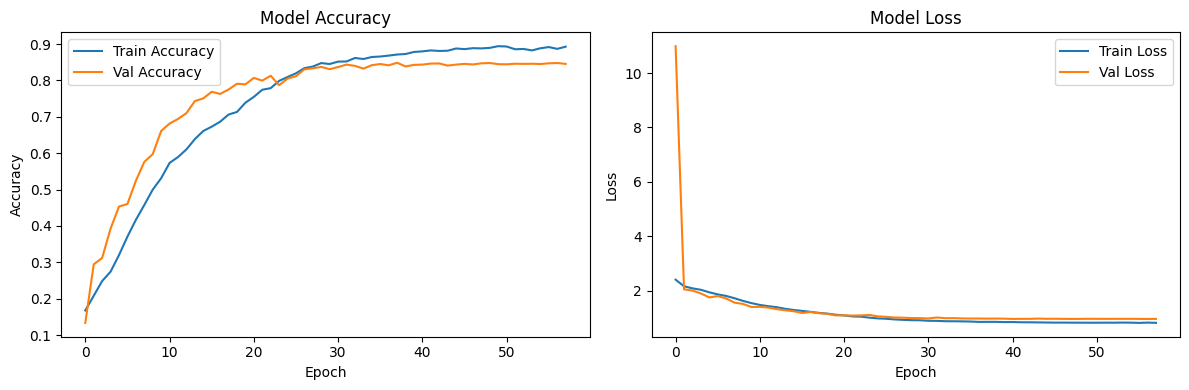

In [47]:
cnn_val_acc = evaluate_model(cnn_history)

For Vgg Model

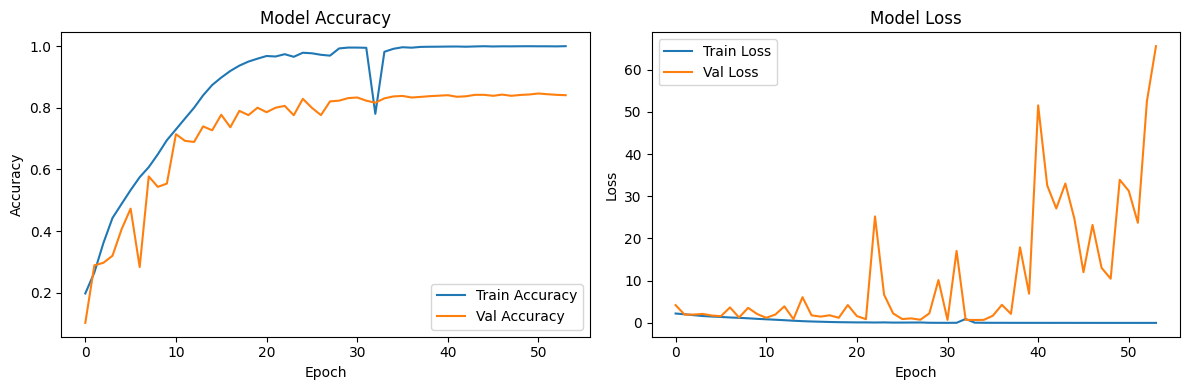

In [48]:
vgg_val_acc = evaluate_model(vgg_history)

For Mobile Net Model

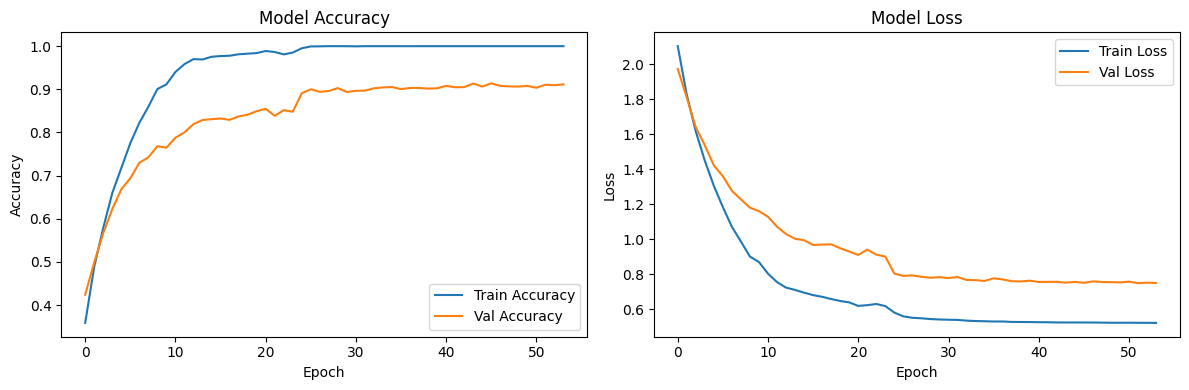

In [66]:
mobile_net_val_acc = evaluate_model(mobile_net_hist)

Check best model

In [67]:
histories = {
    "CNN": cnn_history,
    "VGG": vgg_history,
    "MobileNet": mobile_net_hist
}

def find_best_model(histories, task_type='classification'):
    """
    histories: dict with model names as keys and History objects as values
    task_type: 'classification' or 'regression'
    """
    best_score = -float('inf') if task_type == 'classification' else float('inf')
    best_model = None

    for name, hist in histories.items():
        if task_type == 'classification':
            val_acc = max(hist.history.get('val_categorical_accuracy', [0]))
            print(f"{name}: Best Val Accuracy = {val_acc:.4f}")
            if val_acc > best_score:
                best_score = val_acc
                best_model = name
        elif task_type == 'regression':
            val_mae = min(hist.history.get('val_mae', [float('inf')]))
            print(f"{name}: Best Val MAE = {val_mae:.4f}")
            if val_mae < best_score:
                best_score = val_mae
                best_model = name

    print(f"\nBest model: {best_model} with {'accuracy' if task_type == 'classification' else 'MAE'} = {best_score:.4f}")
    return best_model


find_best_model(histories, 'classification')

CNN: Best Val Accuracy = 0.8485
VGG: Best Val Accuracy = 0.8462
MobileNet: Best Val Accuracy = 0.9138

Best model: MobileNet with accuracy = 0.9138


'MobileNet'

In [69]:
histories = {
    "CNN": cnn_history,
    "VGG": vgg_history,
    "MobileNet": mobile_net_hist
}

def find_best_model(histories, metric='val_categorical_accuracy'):
    best_score = float('-inf')
    best_model = None

    for name, hist in histories.items():
        score = max(hist.history.get(metric, [0]))
        print(f"{name}: Best {metric} = {score:.4f}")
        if score > best_score:
            best_score = score
            best_model = name

    print(f"\nBest model: {best_model} with {metric} = {best_score:.4f}")
    return best_model

find_best_model(histories, metric='val_categorical_accuracy')  # accuracy
find_best_model(histories, metric='val_loss')  # lowest loss

CNN: Best val_categorical_accuracy = 0.8485
VGG: Best val_categorical_accuracy = 0.8462
MobileNet: Best val_categorical_accuracy = 0.9138

Best model: MobileNet with val_categorical_accuracy = 0.9138
CNN: Best val_loss = 10.9856
VGG: Best val_loss = 65.5480
MobileNet: Best val_loss = 1.9730

Best model: VGG with val_loss = 65.5480


'VGG'